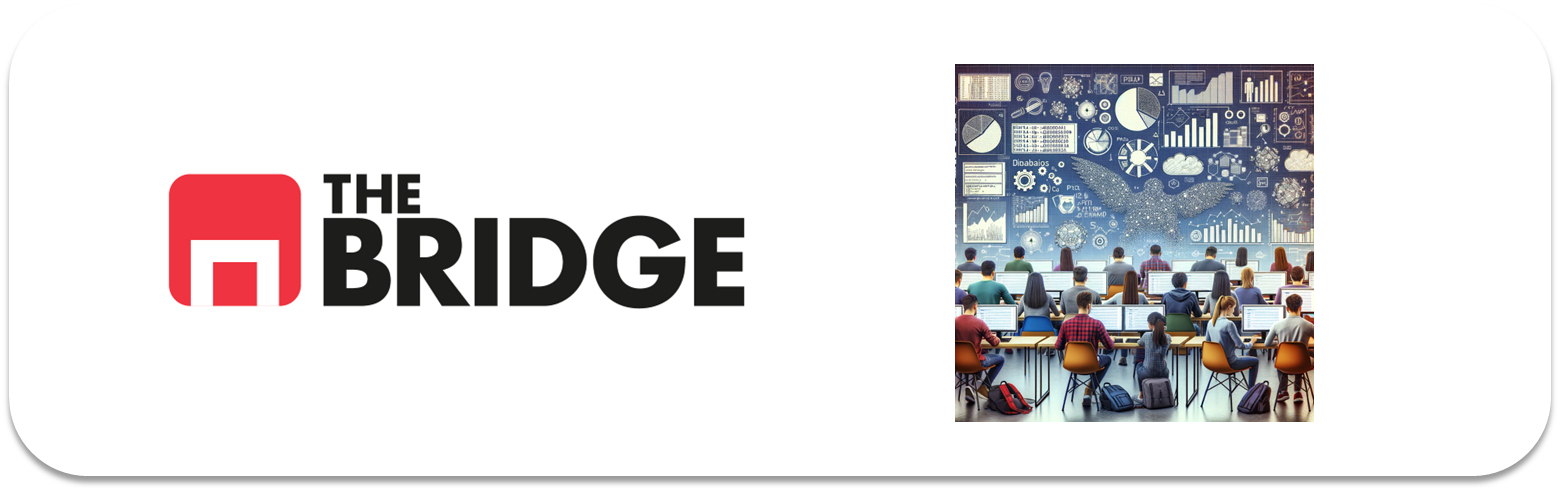

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn import metrics

In [2]:
df = pd.read_csv("./data/hard_to_find/obligatoria_hard.csv", sep="|")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


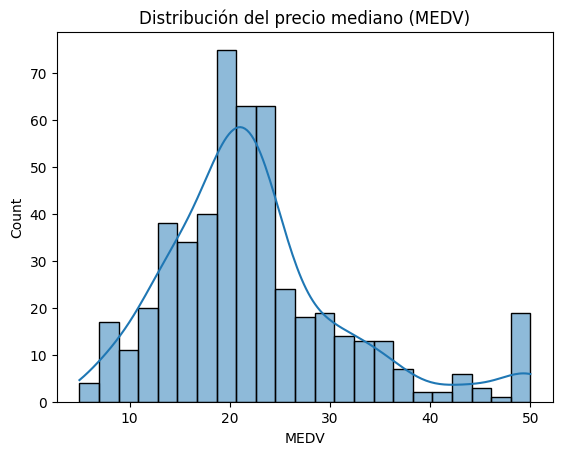

In [4]:
target = "MEDV"

sns.histplot(x=target, data=df, kde=True)
plt.title("Distribución del precio mediano (MEDV)")
plt.show()

In [5]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print(train_set.shape)
print(test_set.shape)

(404, 13)
(102, 13)


In [7]:
corr = train_set.corr(numeric_only=True)

serie_corr = np.abs(corr[target]).sort_values(ascending=False)
print(serie_corr)


MEDV       1.000000
LSTAT      0.736422
RM         0.710680
PTRATIO    0.491210
INDUS      0.470546
TAX        0.459795
NOX        0.415768
RAD        0.387467
CRIM       0.380091
AGE        0.340216
ZN         0.309504
DIS        0.235114
CHAS       0.190642
Name: MEDV, dtype: float64


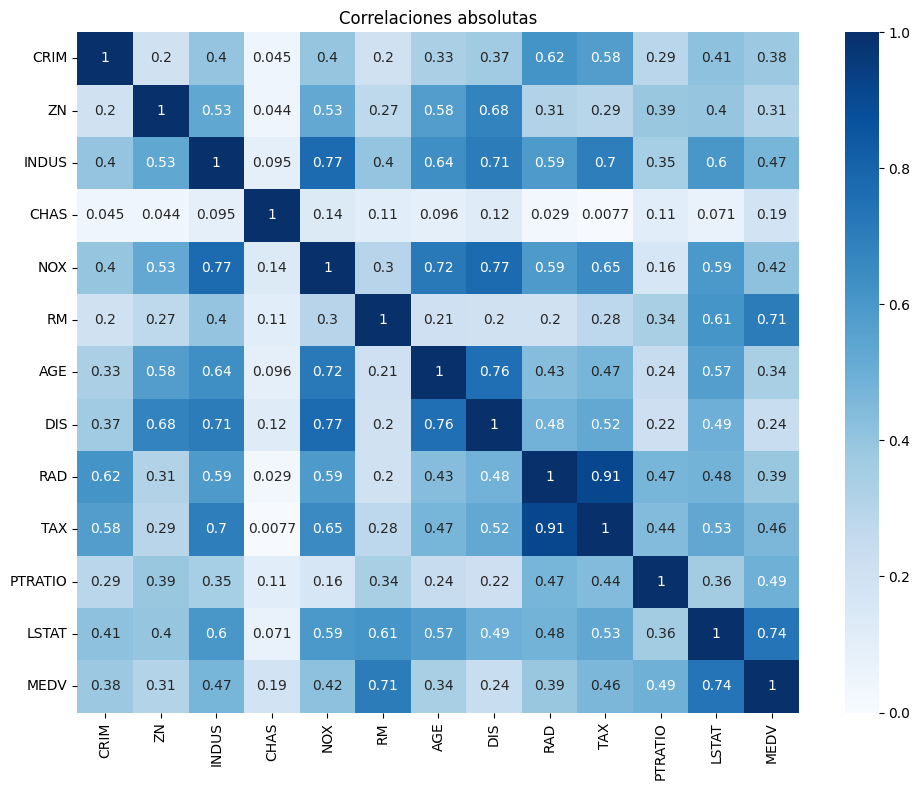

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(np.abs(train_set.corr(numeric_only=True)), annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlaciones absolutas")
plt.tight_layout()
plt.show()

In [9]:
criterio = 0.31

features_num = serie_corr[serie_corr > criterio].index.to_list()
features_num.remove(target)
if "RAD" in features_num:
    features_num.remove("RAD")   # categórica

print("Features numéricas seleccionadas:", features_num)

Features numéricas seleccionadas: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM', 'AGE']


In [10]:
criterio_col = 0.7
excluidas = []
corr_numeric = train_set[features_num].corr(numeric_only=True)

for col in features_num:
    if col not in excluidas:
        for col_2, valor_corr in corr_numeric[col].items():
            if col != col_2 and col_2 in features_num:
                if np.abs(valor_corr) >= criterio_col:
                    print(f"{col} correla con {col_2} al {valor_corr:.4f} --> EXCLUIMOS {col_2}")
                    excluidas.append(col_2)

excluidas = list(set(excluidas))
for excluida in excluidas:
    features_num.remove(excluida)

print("\nFeatures numéricas finales:", features_num)

INDUS correla con TAX al 0.7024 --> EXCLUIMOS TAX
INDUS correla con NOX al 0.7710 --> EXCLUIMOS NOX
AGE correla con NOX al 0.7204 --> EXCLUIMOS NOX

Features numéricas finales: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'CRIM', 'AGE']


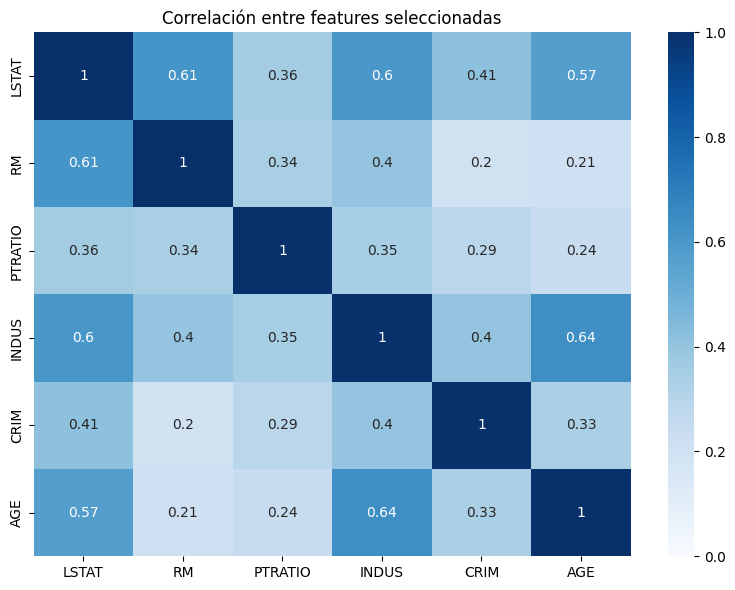

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(np.abs(train_set[features_num].corr()), annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlación entre features seleccionadas")
plt.tight_layout()
plt.show()

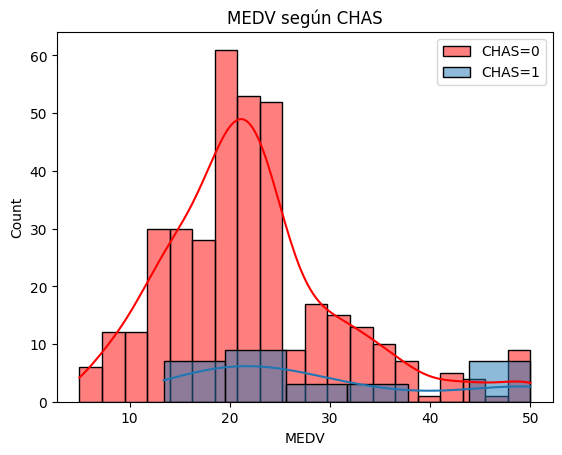

In [13]:
features_cat = ["CHAS", "RAD"]
sns.histplot(x=target, data=train_set[train_set.CHAS == 0], kde=True, color="red", label="CHAS=0")
sns.histplot(x=target, data=train_set[train_set.CHAS == 1], kde=True, label="CHAS=1")
plt.legend()
plt.title("MEDV según CHAS")
plt.show()

In [14]:
print(train_set["RAD"].value_counts(normalize=True))

RAD
24.0    0.250000
5.0     0.232673
4.0     0.198020
3.0     0.079208
6.0     0.056931
2.0     0.051980
8.0     0.051980
1.0     0.042079
7.0     0.037129
Name: proportion, dtype: float64


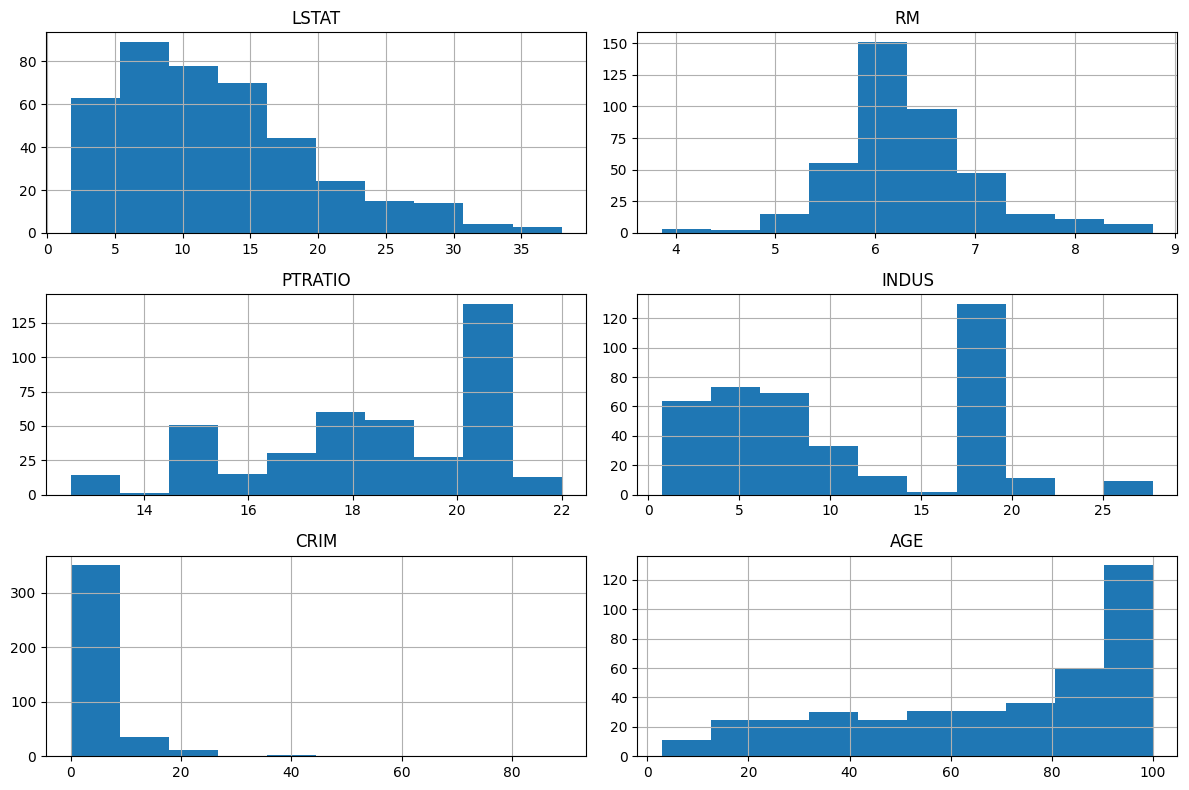

In [15]:
train_set[features_num].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

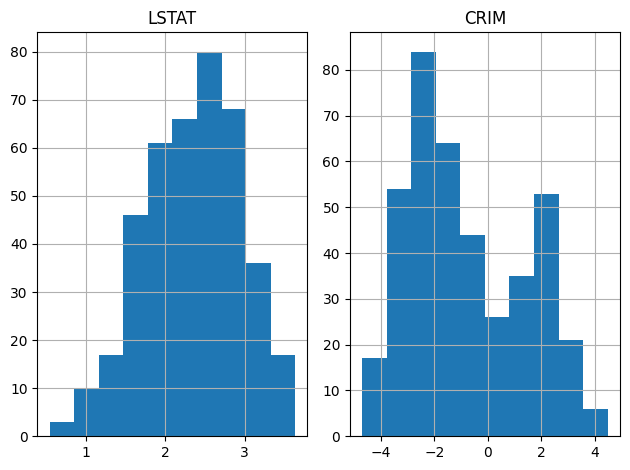

In [16]:
features_transform = ["LSTAT", "CRIM"]

for feature in features_transform:
    if feature in features_num:
        train_set[feature] = train_set[feature].apply(np.log)
        test_set[feature] = test_set[feature].apply(np.log)

train_set[features_transform].hist()
plt.tight_layout()
plt.show()

In [17]:
scaler = StandardScaler()
scaler.fit(train_set[features_num])   # fit solo con train

train_set[features_num] = scaler.transform(train_set[features_num])
test_set[features_num] = scaler.transform(test_set[features_num])

train_set[features_num].describe()

,LSTAT,RM,PTRATIO,INDUS,CRIM,AGE
count,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02
mean,1.648846e-18,-2.616169e-16,8.519038e-16,-4.177077e-17,-3.297692e-18,-4.858600e-16
std,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00
min,-3.000707e+00,-3.461733e+00,-2.568944e+00,-1.487791e+00,-1.831385e+00,-2.348206e+00
25%,-7.325080e-01,-6.003488e-01,-6.821011e-01,-8.502733e-01,-8.075264e-01,-8.228264e-01
50%,6.221804e-02,-1.494427e-01,1.714705e-01,-3.521669e-01,-2.637886e-01,3.270201e-01
75%,7.345853e-01,4.528240e-01,8.453428e-01,1.033237e+00,9.044722e-01,8.974727e-01
max,2.132647e+00,3.477564e+00,1.653990e+00,2.433163e+00,2.454541e+00,1.124581e+00


In [18]:
features_all = features_num + features_cat
print("Features del modelo:", features_all)

X_train = train_set[features_all]
y_train = train_set[target]

X_test = test_set[features_all]
y_test = test_set[target]

Features del modelo: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'CRIM', 'AGE', 'CHAS', 'RAD']


In [19]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Intercept:", lin_reg.intercept_)
pd.DataFrame(lin_reg.coef_, index=features_all, columns=["Coeficiente"])

Intercept: 22.76086760016005


,Coeficiente
LSTAT,-5.899175
RM,2.186214
PTRATIO,-1.532927
INDUS,-0.222621
CRIM,-0.015794
AGE,1.161619
CHAS,2.796782
RAD,-0.017645


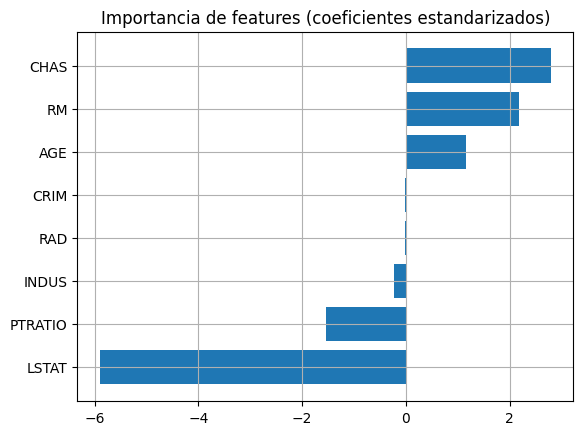

In [20]:
coef_df = pd.DataFrame(lin_reg.coef_, index=features_all, columns=["Coeficiente"]).sort_values("Coeficiente")
plt.barh(coef_df.index, coef_df["Coeficiente"])
plt.title("Importancia de features (coeficientes estandarizados)")
plt.grid()
plt.show()

In [21]:
y_pred_train = lin_reg.predict(X_train)
print("--- TRAIN ---")
print("MAE:",  metrics.mean_absolute_error(y_train, y_pred_train))
print("MSE:",  metrics.mean_squared_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("R2:",   lin_reg.score(X_train, y_train))

--- TRAIN ---
MAE: 3.420618254595861
MSE: 21.423656897295132
RMSE: 4.628569638375891
R2: 0.7533922241784252


In [22]:
y_pred_test = lin_reg.predict(X_test)
print("--- TEST ---")
print("MAE:",  metrics.mean_absolute_error(y_test, y_pred_test))
print("MSE:",  metrics.mean_squared_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("R2:",   lin_reg.score(X_test, y_test))

--- TEST ---
MAE: 2.796334576368189
MSE: 20.27139232240929
RMSE: 4.502376297291164
R2: 0.7235736184768786


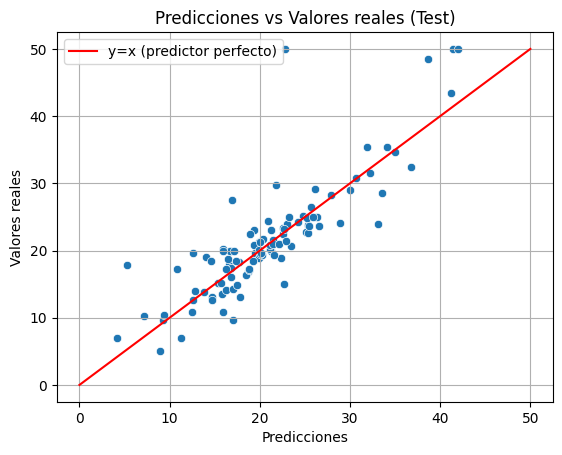

In [24]:
sns.scatterplot(x=y_pred_test, y=y_test)
plt.plot([0, 50], [0, 50], 'r', label="y=x (predictor perfecto)")
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")
plt.title("Predicciones vs Valores reales (Test)")
plt.legend()
plt.grid()
plt.show()


In [25]:
print("=== RIDGE ===")
for alpha in [1, 10, 100]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    print(f"\nalpha={alpha}")
    print("  MAE: ",  metrics.mean_absolute_error(y_test, y_pred))
    print("  RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
    print("  R2:  ", ridge.score(X_test, y_test))

=== RIDGE ===

alpha=1
  MAE:  2.7974548609067
  RMSE: 4.505059195617936
  R2:   0.7232440836762587

alpha=10
  MAE:  2.805074423940974
  RMSE: 4.531170878596694
  R2:   0.7200265873893813

alpha=100
  MAE:  2.919064277660079
  RMSE: 4.743904300903977
  R2:   0.6931205912705276


## Conclusiones

El target **MEDV** tiene una distribución bastante normalita, lo que nos da luz verde para usar regresión lineal sin demasiados remordimientos.

Del mini-EDA sale lo que cualquiera con dos dedos de frente esperaría: **a más habitaciones (RM), más caro el piso**, y **a más pobres los vecinos (LSTAT), más barato**. 

El modelo de regresión lineal base saca un **R² de ~0.75 en test**, que no está mal para ser el modelo más simple del universo. Eso sí, el error en train es algo mejor que en test, señal de que hay un pelín de overfitting, pero nada dramático, el modelo no se ha aprendido los datos de memoria.

Al meter **Ridge con alpha=10**, los errores de train y test se acercan un poco más, lo que significa que el modelo generaliza algo mejor, al precio de equivocarse un pelín más en cada predicción individual. Ese es el trato con la regularización: **menos divo en train, más fiable en la vida real**.

Con alpha=1 casi no nota la regularización, y con alpha=100 ya le estamos apretando demasiado las tuercas y empieza a perder precisión sin ganar gran cosa.

**Me quedo con Ridge alpha=10.** No es el más listo de la clase en train, pero es el que mejor se porta cuando llegan datos nuevos, que al final es lo único que importa.